# Flow sampler on the chain-propagation problem

Reproduction of `maxent_tests/tn_chain_born.ipynb` with the invertible
**flow sampler** (`FlowSamplerModel`, exact joint entropy) instead of a
tensor-chain Born machine. Chains of dependencies are the stress test for
sampler models: every conditional links adjacent variables, and the marginals
of the later variables are determined only through propagation.

The chain `x0 -> x1 -> ... -> x{N-1}` on `[0, 100]`, with **local** constraints
(variable length, default `NVAR = 5`):

    P(x0 > 50)              = 0.70
    P(x_i > 50 | x_{i-1} > 50) = 0.70      for i = 1..N-1
    P(x_i < 50 | x_{i-1} < 50) = 0.95

The **propagated** marginals are *not* fit directly — they must emerge by the
law of total probability:

    p_i = 0.70 * p_{i-1} + 0.05 * (1 - p_{i-1})

The maxent ground truth is fully analytic here: a Markov chain, uniform within
each half, whose joint entropy is

    H* = N*log(50) + h2(0.70) + sum_i [ p_{i-1}*h2(0.70) + (1-p_{i-1})*h2(0.95) ]

so we can score the fit's exact entropy against the true optimum.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import numpy as np
import matplotlib.pyplot as plt
from calibrated_response.tn import ContinuousVar
from calibrated_response.maxent_sampler import (
    FlowSamplerModel, soft_gt, soft_lt, plot_pairwise)

NVAR = 5                      # chain length (edit me)
P0, P_UU, P_DD = 0.70, 0.70, 0.95
W = 1.0 / (2 * 0.05**2)       # probability constraints, value_sd = 0.05
SHARP = 0.3                   # soft-indicator sharpness on the [0,100] domain

vars_ = [ContinuousVar(f"x{i}", 0.0, 100.0, 20) for i in range(NVAR)]

def chain_constraints():
    cons = [("expect", soft_gt(0, 50.0, SHARP), P0, W)]
    for i in range(1, NVAR):
        cons.append(("cond_expect", soft_gt(i, 50.0, SHARP),
                     soft_gt(i - 1, 50.0, SHARP), P_UU, W))
        cons.append(("cond_expect", soft_lt(i, 50.0, SHARP),
                     soft_lt(i - 1, 50.0, SHARP), P_DD, W))
    return cons

# analytic propagated marginals + maxent entropy
p_up = [P0]
for i in range(1, NVAR):
    p_up.append(P_UU * p_up[-1] + (1 - P_DD) * (1 - p_up[-1]))
h2 = lambda p: -p * np.log(p) - (1 - p) * np.log(1 - p)
H_STAR = (NVAR * np.log(50.0) + h2(P0)
          + sum(p_up[i - 1] * h2(P_UU) + (1 - p_up[i - 1]) * h2(P_DD)
                for i in range(1, NVAR)))
print("analytic propagated marginals:", np.round(p_up, 3))
print(f"analytic maxent entropy H* = {H_STAR:.2f} nats")

analytic propagated marginals: [0.7   0.505 0.378 0.296 0.242]
analytic maxent entropy H* = 21.74 nats


### Fit

Soft-constrained maxent: constraint penalties minus the **exact** joint entropy
(`entropy_reg=1.0`), fresh latent batch every Adam step. Conditional
constraints divide by `E[cond]`, so the batch must keep the conditioning events
populated — 2048 works comfortably here (`P(x_i<50)` never drops below ~0.3).

In [2]:
fm = FlowSamplerModel(vars_, n_layers=8, hidden=64)
p_fit, hist = fm.optimize(
    fm.constraint_loss(chain_constraints(), n_samples=2048, entropy_reg=1.0),
    backend="adam", steps=4000, lr=1e-3)
print(f"minibatch loss (noisy): {hist[0]:.2f} -> {np.mean(hist[-100:]):.2f}")

minibatch loss (noisy): 186.63 -> -20.71


### Report — local constraints, propagated marginals, entropy

All read from fresh samples with **hard** indicators (the soft features are only
inside the loss).

In [3]:
x = fm.sample(p_fit, 50000, seed=7)
up = x > 50.0

print("local constraints (fit directly):")
print(f"  P(x0>50)            = {up[:, 0].mean():.3f}   (target {P0:.2f})")
for i in range(1, NVAR):
    puu = up[up[:, i - 1], i].mean()
    pdd = (~up[~up[:, i - 1], i]).mean()
    print(f"  P(x{i}>50|x{i-1}>50) = {puu:.3f} ({P_UU:.2f})    "
          f"P(x{i}<50|x{i-1}<50) = {pdd:.3f} ({P_DD:.2f})")

print("propagated marginals (NOT fit directly):")
for i in range(NVAR):
    print(f"  P(x{i}>50) = {up[:, i].mean():.3f}   (analytic {p_up[i]:.3f})")

C = np.corrcoef(x.T)
print("adjacent correlations:",
      " ".join(f"x{i}x{i+1}={C[i, i+1]:+.2f}" for i in range(NVAR - 1)))
print(f"exact H(x) = {fm.entropy(p_fit, seed=11):.2f}   (maxent optimum H* = {H_STAR:.2f})")

local constraints (fit directly):
  P(x0>50)            = 0.693   (target 0.70)
  P(x1>50|x0>50) = 0.711 (0.70)    P(x1<50|x0<50) = 0.967 (0.95)
  P(x2>50|x1>50) = 0.710 (0.70)    P(x2<50|x1<50) = 0.967 (0.95)
  P(x3>50|x2>50) = 0.727 (0.70)    P(x3<50|x2<50) = 0.959 (0.95)
  P(x4>50|x3>50) = 0.736 (0.70)    P(x4<50|x3<50) = 0.956 (0.95)
propagated marginals (NOT fit directly):
  P(x0>50) = 0.693   (analytic 0.700)
  P(x1>50) = 0.503   (analytic 0.505)
  P(x2>50) = 0.374   (analytic 0.378)
  P(x3>50) = 0.298   (analytic 0.296)
  P(x4>50) = 0.250   (analytic 0.242)
adjacent correlations: x0x1=+0.60 x1x2=+0.69 x2x3=+0.68 x3x4=+0.70


exact H(x) = 21.07   (maxent optimum H* = 21.74)


### Pairwise marginals vs the exact maxent reference

The true maxent distribution is samplable in closed form (Markov half-choices,
uniform within each half) — overlaid in red on the flow's sample histograms.

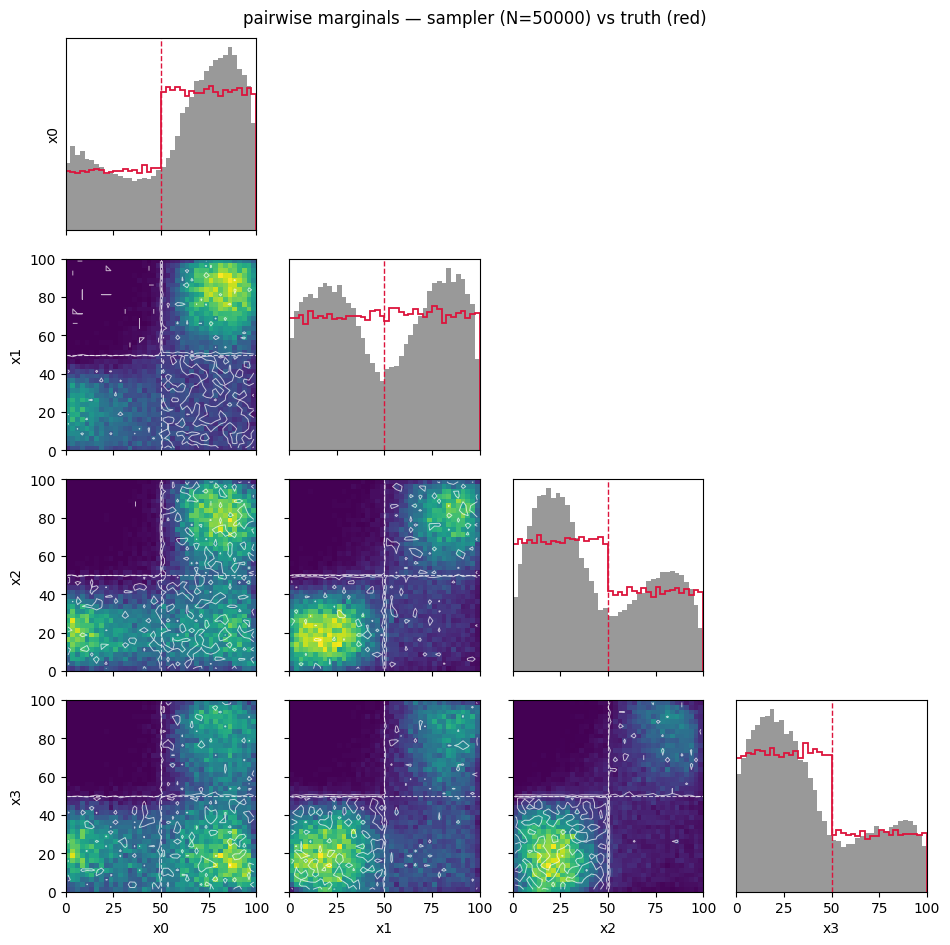

In [4]:
def sample_reference(N=50000, seed=3):
    rng = np.random.default_rng(seed)
    draw = lambda hi: np.where(hi, rng.uniform(50, 100, len(hi)),
                               rng.uniform(0, 50, len(hi)))
    cols = [draw(rng.random(N) < P0)]
    for i in range(1, NVAR):
        prev_up = cols[-1] > 50
        pr = np.where(prev_up, P_UU, 1 - P_DD)
        cols.append(draw(rng.random(N) < pr))
    return np.stack(cols, axis=1)

x_ref = sample_reference()
sites = list(range(min(NVAR, 4)))
_FIG = plot_pairwise(fm, p_fit, sites=sites, names=[f"x{i}" for i in sites],
                     n_samples=50000, seed=7, bins=40, threshold=50,
                     ref_samples=x_ref[:, sites])[0]

### Notes

- The tensor chain solves this with **exact** contractions (constraint residual
  ~1e-12); the sampler's residuals are Monte-Carlo scale (~0.01-0.03 on the deep
  conditionals). What matters is that propagation *works*: the unfit marginals
  land on the analytic recursion and the exact entropy sits within a fraction of
  a nat per variable of the analytic optimum `H*`.
- `SHARP` trades gradient flow against indicator bias: the loss fits the
  *smoothed* probability `E[sigmoid(SHARP*(x-50))]`, which differs from the hard
  `P(x>50)` where the density is asymmetric near the threshold. Sharpen it (and
  raise `n_samples`) if the hard-indicator readouts drift.
- Longer chains (`NVAR = 10+`) mostly need more steps: the marginal signal for
  the tail variables arrives only through the chain of conditionals.